# Pregunta del negocio
Cómo influyen los días de la semana en la efectividad de
nuestras campañas de marketing, y qué días deberían ser priorizados para maximizar el éxito
de nuestras estrategias de contacto?


# Librerias

In [65]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [66]:
path = "/Users/ekaterinasorokopudova/Desktop/simulador/ProjecteData/Equip_21/Data/Silver_BANK_marketing_020226.csv"

In [67]:
df = pd.read_csv(
    path,
    sep=",",
    encoding="utf-8"
)

In [68]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11145,11158,33,blue-collar,single,primary,0,1.0,1,0,cellular,20,apr,257,1,-1,0,new_marketing_client,0
11146,11159,39,services,married,secondary,0,733.0,0,0,undefined_contact_type,16,jun,83,4,-1,0,new_marketing_client,0
11147,11160,32,technician,single,secondary,0,29.0,0,0,cellular,19,aug,156,2,-1,0,new_marketing_client,0
11148,11161,43,technician,married,secondary,0,0.0,0,1,cellular,8,may,9,2,172,5,failure,0


# Limitaciones del dataset

# 1. Año 

In [69]:
year_analisis = (
    df
    .groupby('month')
    .agg(
        conversion=('deposit', 'mean'),
        llamadas=('deposit', 'count')
    )
)

year_analisis = year_analisis.sort_values('conversion', ascending=True)
year_analisis 

,conversion,llamadas
month,,
may,0.327311,2823
jan,0.412791,344
jul,0.414570,1510
nov,0.426752,942
jun,0.447174,1221
aug,0.452868,1517
feb,0.569032,775
apr,0.625135,923
oct,0.823980,392


In [70]:
orden_meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

year_analisis = year_analisis.reindex(orden_meses)

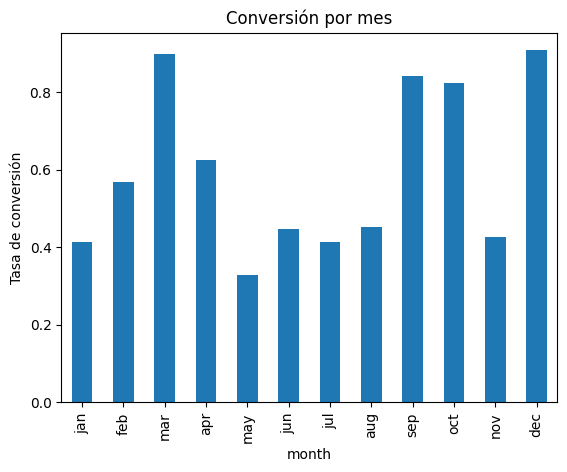

In [71]:
year_analisis['conversion'].plot(kind='bar')
plt.title('Conversión por mes')
plt.ylabel('Tasa de conversión')
plt.show()

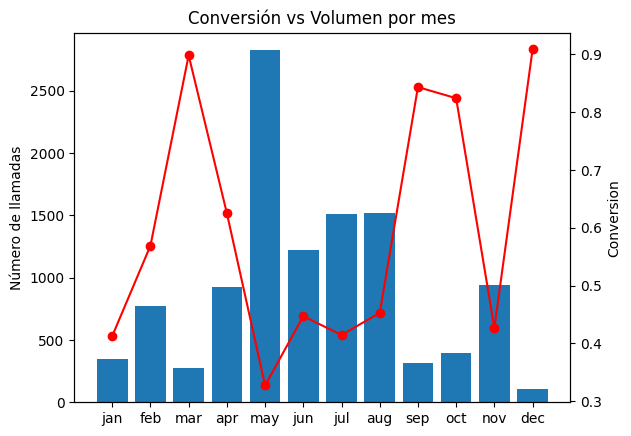

In [72]:
fig, ax1 = plt.subplots()

# Eje para llamadas
ax1.bar(year_analisis.index, year_analisis['llamadas'])
ax1.set_ylabel('Número de llamadas')

# Conversión
ax2 = ax1.twinx()
ax2.plot(year_analisis.index, year_analisis['conversion'], marker='o', color= "red")
ax2.set_ylabel('Conversion')

plt.title('Conversión vs Volumen por mes')
plt.show()




Cuatro picos de conversión: marzo, septiembre, octubre y diciembre = ¿estacionalidad?

## Hipótesis 1

- H0: La tasa de conversión es la misma en todos los meses
- H1: La tasa de conversión varía entre meses (posible efecto estacional)

In [73]:
contingency_table = pd.crosstab(df['month'], df['deposit'])

contingency_table

deposit,0,1
month,,
apr,346,577
aug,830,687
dec,10,99
feb,334,441
jan,202,142
jul,884,626
jun,675,546
mar,28,247
may,1899,924


In [74]:
#Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [75]:
#Cramer's V
n = contingency_table.to_numpy().sum()
r, k = contingency_table.shape
cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

In [76]:
print("=== Chi-square test: month x deposit ===")
print(f"chi2 = {chi2:.4f}")
print(f"dof  = {dof}")
print(f"p    = {p:.6f}")
print(f"Cramer's V = {cramers_v:.4f}")


=== Chi-square test: month x deposit ===
chi2 = 1045.4840
dof  = 11
p    = 0.000000
Cramer's V = 0.3062


p = 0,000000

- Las diferencias en la conversión por mes son estadísticamente significativas
- Se rechaza la hipótesis de que «la CR es la misma para todos los meses».

V de Cramer = 0,3062 

- 0,05 — débil
- 0,10 — moderada
- 0,20 — media
- 0,30 — fuerte

Valor de 0,3062 confirma una fuerte conexión entre CR y Mes

## Hipotesis 2 
- H0: La probabilidad de conversión es la misma en los meses pico y en los meses no pico.
(CR_peak = CR_non_peak)
- H1: La probabilidad de conversión difiere entre los meses pico y los meses no pico.
(CR_peak ≠ CR_non_peak)

In [77]:
peak_months = ['mar', 'sep', 'oct', 'dec']

In [78]:
df['is_peak_month'] = df['month'].isin(peak_months)
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,is_peak_month
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1,False
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1,False
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1,False
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1,False
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11145,11158,33,blue-collar,single,primary,0,1.0,1,0,cellular,20,apr,257,1,-1,0,new_marketing_client,0,False
11146,11159,39,services,married,secondary,0,733.0,0,0,undefined_contact_type,16,jun,83,4,-1,0,new_marketing_client,0,False
11147,11160,32,technician,single,secondary,0,29.0,0,0,cellular,19,aug,156,2,-1,0,new_marketing_client,0,False
11148,11161,43,technician,married,secondary,0,0.0,0,1,cellular,8,may,9,2,172,5,failure,0,False


In [79]:
contingency_table_peak = pd.crosstab(df['is_peak_month'], df['deposit'])
contingency_table_peak


deposit,0,1
is_peak_month,,
False,5710,4345
True,157,938


In [80]:
#Chi-square test
chi2_peak, p_peak, dof_peak, expected_peak = chi2_contingency(contingency_table_peak)

In [81]:
#Cramer's V
n2 = contingency_table_peak.to_numpy().sum()
r2, k2 = contingency_table_peak.shape
cramers_v_peak = np.sqrt((chi2_peak / n2) / (min(r2 - 1, k2 - 1)))

In [82]:

print("=== Chi-square: peak months vs others ===")
print(f"chi2 = {chi2_peak:.4f}")
print(f"dof  = {dof_peak}")
print(f"p    = {p_peak:.6f}")
print(f"Cramer's V = {cramers_v_peak:.4f}")

=== Chi-square: peak months vs others ===
chi2 = 712.0137
dof  = 1
p    = 0.000000
Cramer's V = 0.2527


p = 0,000000

- Las diferencias en la conversión por mes con mejor CR con otros son estadísticamente significativas
- Se rechaza la hipótesis de que «La probabilidad de conversión es la misma en los meses pico y en los meses no pico.».

V de Cramer = 0,3062 

- 0,05 — débil
- 0,10 — moderada
- 0,20 — media
- 0,30 — fuerte

Valor de 0,2527 confirma una alta moderada conexión entre ... 

In [83]:
cr_peak = df.loc[df['is_peak_month'], 'deposit'].mean()
cr_nonpeak = df.loc[~df['is_peak_month'], 'deposit'].mean()

print(f"CR peak months     = {cr_peak:.3%}")
print(f"CR non-peak months = {cr_nonpeak:.3%}")
print(f"Diff (pp)          = {(cr_peak - cr_nonpeak)*100:.2f} pp")


CR peak months     = 85.662%
CR non-peak months = 43.212%
Diff (pp)          = 42.45 pp


## Conclusiones H1 + H2

La probabilidad de conversión depende estadísticamente de forma significativa del mes de contacto.
Esto se confirma mediante la prueba χ² (p < 0,001) y un tamaño del efecto elevado (V de Cramer = 0,31).

Los meses de máxima CR (marzo, septiembre, octubre y diciembre) difieren significativamente de los demás meses.
La diferencia entre los meses de máxima CR y los meses de baja CR es estadísticamente significativa (p < 0,001), con un tamaño del efecto de moderado a elevado (V de Cramer = 0,25).

La diferencia en la conversión entre los grupos es muy grande según los estándares prácticos - 42.45 pp 

Es POSIBLE afirmar

- El mes de contacto está fuertemente asociado con la probabilidad de conversión.
- Las diferencias son estadísticamente significativas y de importancia práctica.
- Los meses de mayor actividad requieren especial atención al planificar las campañas.

NO ES POSIBLE afirmar (todavía).

- Que el mes genere conversión.
- Que el efecto no se explique por los perfiles de los clientes, la estrategia de contacto ni la intensidad de las llamadas.

## ¿Qué más podría influir en la conversión además del mes?

- Efecto del tipo de cliente
- Efecto de la estrategia de contacto
- Ruido

# 2. Mes (intra-mensual temporal effect)

In [84]:
efectividad_dia = (
    df
    .groupby('day')
    .agg(
        conversion=('deposit', 'mean'),
        llamadas=('deposit', 'count')
    )
)

efectividad_dia = efectividad_dia.sort_values('day', ascending=True)
efectividad_dia

,conversion,llamadas
day,,
1,0.737705,122
2,0.543544,333
3,0.581699,306
4,0.573566,401
5,0.450734,477
6,0.403587,446
7,0.410995,382
8,0.479714,419
9,0.491758,364


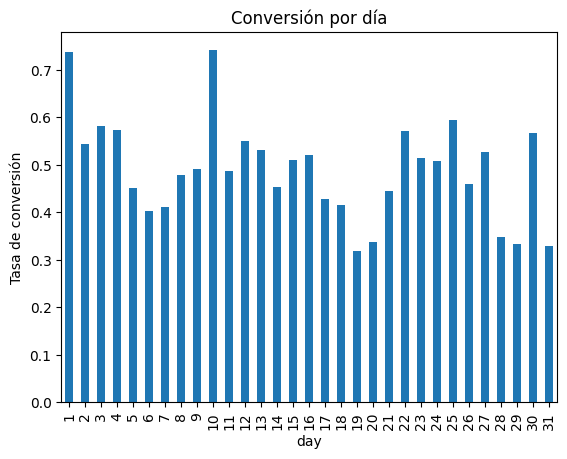

In [85]:
efectividad_dia ['conversion'].plot(kind='bar')
plt.title('Conversión por día')
plt.ylabel('Tasa de conversión')
plt.show()

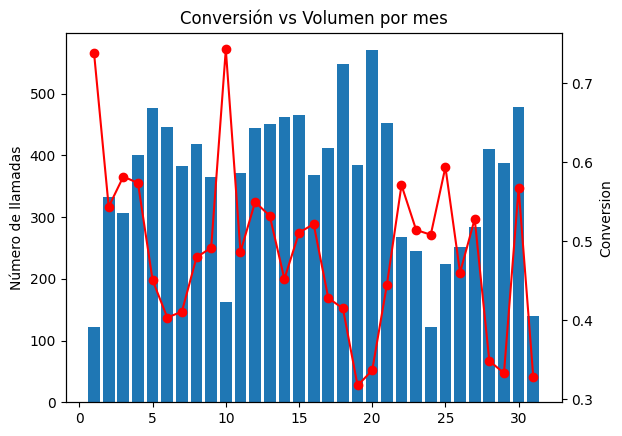

In [86]:
fig, ax1 = plt.subplots()

# Eje para llamadas
ax1.bar(efectividad_dia.index, efectividad_dia['llamadas'])
ax1.set_ylabel('Número de llamadas')

# Conversión
ax2 = ax1.twinx()
ax2.plot(efectividad_dia.index, efectividad_dia['conversion'], marker='o', color= "red")
ax2.set_ylabel('Conversion')

plt.title('Conversión vs Volumen por mes')
plt.show()



Dos picos de conversión: 1 y 10 son aleatorias?
5 días fallidos: 19 20 28 29 и 31 

Tenemps que excluir 31 (?)

## Hipótesis 1

- H0: La conversión es independiente del día del mes.
- H1: La conversión depende del día del mes (al menos un día difiere).


In [87]:
contingency_table_day = pd.crosstab(df['day'], df['deposit'])
contingency_table_day

deposit,0,1
day,,
1,32,90
2,152,181
3,128,178
4,171,230
5,262,215
6,266,180
7,225,157
8,218,201
9,185,179


In [88]:
#Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table_day)

In [89]:
#Cramer's V
n = contingency_table_day.to_numpy().sum()
r, k = contingency_table_day.shape
cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

In [90]:
print("=== Chi-square test: day x deposit ===")
print(f"chi2 = {chi2:.4f}")
print(f"dof  = {dof}")
print(f"p    = {p:.6f}")
print(f"Cramer's V = {cramers_v:.4f}")


=== Chi-square test: day x deposit ===
chi2 = 364.4139
dof  = 30
p    = 0.000000
Cramer's V = 0.1808


## Hipótesis 2

- H0: La tasa de conversión en los días {1,10} es igual a la del resto de días.
- H1: La tasa de conversión en los días {1,10} difiere de la del resto de días.


In [91]:
peak_days = {1, 10}

In [92]:
df['is_peak_day'] = df['day'].isin(peak_days)

In [93]:
ct_peak_day = pd.crosstab(df['is_peak_day'], df['deposit'])
ct_peak_day 

deposit,0,1
is_peak_day,,
False,5793,5072
True,74,211


In [94]:
#Chi-square test
chi2, p, dof, expected = chi2_contingency(ct_peak_day)

In [95]:

#Cramer's V (для 2x2 это phi)
n = ct_peak_day.to_numpy().sum()
cramers_v = np.sqrt((chi2 / n) / (min(ct_peak_day.shape[0]-1, ct_peak_day.shape[1]-1)))

In [96]:

cr_peak = df.loc[df['is_peak_day'], 'deposit'].mean()
cr_rest = df.loc[~df['is_peak_day'], 'deposit'].mean()

In [97]:
print("=== Hipótesis: días {1,10} vs resto ===")
print(f"chi2 = {chi2:.4f}")
print(f"dof  = {dof}")
print(f"p    = {p:.6f}")
print(f"Cramer's V = {cramers_v:.4f}")
print()
print(f"CR días pico (1,10) = {cr_peak:.3%}")
print(f"CR resto días       = {cr_rest:.3%}")
print(f"Diff (pp)           = {(cr_peak - cr_rest)*100:.2f} pp")

=== Hipótesis: días {1,10} vs resto ===
chi2 = 82.2487
dof  = 1
p    = 0.000000
Cramer's V = 0.0859

CR días pico (1,10) = 74.035%
CR resto días       = 46.682%
Diff (pp)           = 27.35 pp


In [98]:
expected_df = pd.DataFrame(expected, index=ct_peak_day.index, columns=ct_peak_day.columns)
print("\nMin expected:", expected_df.min().min())
print("Cells with expected < 5:", (expected_df < 5).sum().sum(), "/", expected_df.size)


Min expected: 135.03632286995514
Cells with expected < 5: 0 / 4


## Hipótesis 3

- H0: La tasa de conversión en los días {19,20,28,29} es igual a la del resto de días.
- H1: La tasa de conversión en los días {19,20,28,29} difiere de la del resto de días.

In [99]:
failed_days = {19, 20, 28, 29}

In [100]:
df['is_failed_day'] = df['day'].isin(failed_days)

In [101]:
ct_failed_day = pd.crosstab(df['is_failed_day'], df['deposit'])
ct_failed_day

deposit,0,1
is_failed_day,,
False,4702,4697
True,1165,586


In [102]:
#Chi-square test
chi2, p, dof, expected = chi2_contingency(ct_failed_day)

In [103]:
# Cramer's V
n = ct_failed_day.to_numpy().sum()
cramers_v = np.sqrt((chi2 / n) / (min(ct_failed_day.shape[0]-1, ct_failed_day.shape[1]-1)))

In [104]:
cr_failed = df.loc[df['is_failed_day'], 'deposit'].mean()
cr_rest   = df.loc[~df['is_failed_day'], 'deposit'].mean()

In [105]:
print("=== Hipótesis: días {19,20,28,29} vs resto ===")
print()
print(f"chi2 = {chi2:.4f}")
print(f"dof  = {dof}")
print(f"p    = {p:.6f}")
print(f"Cramer's V = {cramers_v:.4f}")
print()
print(f"CR días fallidos (19,20,28,29) = {cr_failed:.3%}")
print(f"CR resto días                  = {cr_rest:.3%}")
print(f"Diff (pp)                      = {(cr_failed - cr_rest)*100:.2f} pp")

=== Hipótesis: días {19,20,28,29} vs resto ===

chi2 = 160.6527
dof  = 1
p    = 0.000000
Cramer's V = 0.1200

CR días fallidos (19,20,28,29) = 33.467%
CR resto días                  = 49.973%
Diff (pp)                      = -16.51 pp


In [106]:
expected_df = pd.DataFrame(expected, index=ct_failed_day.index, columns=ct_failed_day.columns)
print("\nMin expected:", expected_df.min().min())
print("Cells with expected < 5:", (expected_df < 5).sum().sum(), "/", expected_df.size)



Min expected: 829.6442152466368
Cells with expected < 5: 0 / 4


## Conclusiones 
- Las diferencias entre los días del mes no son aleatorias.
- La magnitud del efecto es moderada, pero constante.
- El día del mes es un factor real que influye en la CR, aunque con menor intensidad que el mes.

- Los días 1 y 10 se caracteriza por una eficiencia de contacto significativamente mayor.
- Esto no es solo ruido ni casualidad.

- Los días 19,20,28,29 muestran una disminución sistemática de la eficiencia


Es POSIBLE afirmar:

- que el día del mes está asociado con la conversión.
- que los grupos de días identificados son realmente diferentes.
- que el tiempo dentro de un mes es importante para la planificación de contactos.

que NO ES POSIBLE afirmar:

- que un día específico "provoca" la conversión.
- que considera los días 1 y 10 como días "mágicos".
- que saca conclusiones sin considerar el contexto ni el perfil del cliente.

# ¿El patrón persiste cuando se agrupan los días?

In [107]:
def tramo_mes(day):
    if day <= 10:
        return 'inicio'
    elif day <= 20:
        return 'medio'
    else:
        return 'fin'

In [108]:
df['tramo_mes'] = df['day'].apply(tramo_mes)

orden_tramos = ['inicio','medio','fin']

In [109]:
df['day_group'] = pd.cut(
    df['day'],
    bins=[0,5,10,15,20,25,31],
    labels=['1-5','6-10','11-15','16-20','21-25','26-31']
)

In [110]:
df.groupby('day')['deposit'].mean().sort_values(ascending=False)

day
10    0.742331
1     0.737705
25    0.593750
3     0.581699
4     0.573566
22    0.570896
30    0.566946
12    0.549550
2     0.543544
13    0.532151
27    0.528169
16    0.521739
23    0.514286
15    0.510730
24    0.508197
9     0.491758
11    0.486559
8     0.479714
26    0.460317
14    0.452381
5     0.450734
21    0.444690
17    0.428224
18    0.414991
7     0.410995
6     0.403587
28    0.348780
20    0.336842
29    0.333333
31    0.328571
19    0.317708
Name: deposit, dtype: float64

In [111]:
df.groupby('tramo_mes')['deposit'].mean()

tramo_mes
fin       0.469037
inicio    0.507471
medio     0.451620
Name: deposit, dtype: float64

In [112]:
df.groupby(['month', 'tramo_mes'])['deposit'].mean()

month  tramo_mes
apr    fin          0.854489
       inicio       0.604938
       medio        0.463470
aug    fin          0.297539
       inicio       0.596618
       medio        0.467988
dec    fin          0.911765
       inicio       0.901961
       medio        0.916667
feb    fin          0.864865
       inicio       0.429091
       medio        0.933775
jan    fin          0.298932
       inicio       1.000000
       medio        0.916667
jul    fin          0.343096
       inicio       0.492462
       medio        0.465823
jun    fin          0.677419
       inicio       0.497561
       medio        0.345029
mar    fin          0.876712
       inicio       0.928571
       medio        0.868421
may    fin          0.334211
       inicio       0.295775
       medio        0.342434
nov    fin          0.409091
       inicio       0.802083
       medio        0.376543
oct    fin          0.914573
       inicio       0.727273
       medio        0.731884
sep    fin          0.8253

In [113]:
df.groupby('tramo_mes').size()

tramo_mes
fin       3262
inicio    3413
medio     4475
dtype: int64

## Hipotesis 1

H0: CR одинаков в inicio / medio / fin

H1: CR различается между tramo_mes

In [114]:
tabla_mt = pd.crosstab(
    [df['month'], df['tramo_mes']],
    df['deposit']
)

In [115]:
chi2, p, dof, expected = chi2_contingency(tabla_mt)

In [116]:
n = tabla_mt.values.sum()
k = min(tabla_mt.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))

In [117]:
print("=== Chi-square test: tramo x deposit ===")
print(f"chi2 = {chi2:.4f}")
print(f"dof  = {dof}")
print(f"p    = {p:.6f}")
print(f"Cramer's V = {cramers_v:.4f}")

=== Chi-square test: tramo x deposit ===
chi2 = 1623.7908
dof  = 35
p    = 0.000000
Cramer's V = 0.3816


- Las diferencias entre inicio/medio/fin son extremadamente significativas.
- El tamaño del efecto es alto (0,38 ya constituye una asociación sólida).
- Efecto estructural intramensual.

In [118]:
tabla_prop_mt = pd.crosstab(
    [df['month'], df['tramo_mes']],
    df['deposit'],
    normalize='index'
)
tabla_heat = tabla_prop_mt[1].unstack().reindex(
    index=orden_meses,
    columns=orden_tramos
)

## Sensitivity analysis

In [119]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

In [120]:
tramo_order = ['inicio', 'medio', 'fin']

In [121]:
heat_map_tab = (
    df
    .groupby(['month', 'tramo_mes'])
    .agg(
        CR=('deposit', 'mean'),
        volumen=('deposit', 'count')
    )
    .round(2)
    .reset_index()
)

In [122]:
heat_map_tab['month'] = pd.Categorical(
    heat_map_tab['month'],
    categories=month_order,
    ordered=True
)

heat_map_tab['tramo_mes'] = pd.Categorical(
    heat_map_tab['tramo_mes'],
    categories=tramo_order,
    ordered=True
)

heat_map_tab = heat_map_tab.sort_values(['month', 'tramo_mes'])
heat_map_tab

,month,tramo_mes,CR,volumen
13,jan,inicio,1.00,3
14,jan,medio,0.92,60
12,jan,fin,0.30,281
10,feb,inicio,0.43,550
11,feb,medio,0.93,151
9,feb,fin,0.86,74
22,mar,inicio,0.93,126
23,mar,medio,0.87,76
21,mar,fin,0.88,73
1,apr,inicio,0.60,162


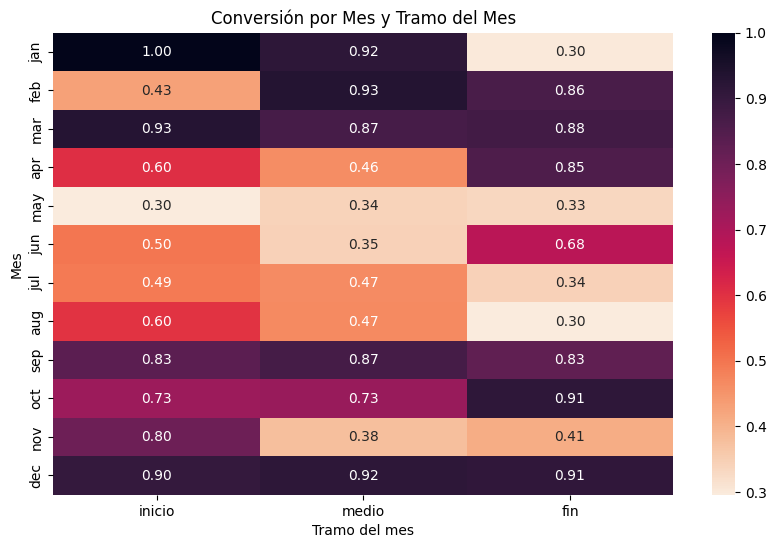

In [123]:
plt.figure(figsize=(10,6))

sns.heatmap(
    tabla_heat,
    annot=True,
    fmt=".2f",
    cmap='rocket_r'
)

plt.title('Conversión por Mes y Tramo del Mes')
plt.ylabel('Mes')
plt.xlabel('Tramo del mes')

plt.show()

El gráfico muestra los valores de cada período y cada mes. No es muy fácil de leer y presenta inestabilidad local, lo que revela ruido en los datos.
Por lo tanto, se decidió verificar los valores e identificar el pottern en los valores promedio utilizando Sensitivity analysis

In [124]:
months = df['month'].unique()

results = []

for m in months:
    tmp = df[df['month'] != m]
    cr_by_tramo = (
        tmp
        .groupby('tramo_mes')['deposit']
        .mean()
    )
    results.append({
        'excluded_month': m,
        'inicio': cr_by_tramo.get('inicio', None),
        'medio': cr_by_tramo.get('medio', None),
        'fin': cr_by_tramo.get('fin', None),
    })

robustness_df = pd.DataFrame(results)
robustness_df

,excluded_month,inicio,medio,fin
0,may,0.570289,0.495459,0.509992
1,jun,0.509650,0.465422,0.462922
2,jul,0.509453,0.450245,0.504519
3,aug,0.495165,0.448809,0.496270
4,oct,0.503871,0.442702,0.440091
5,nov,0.498945,0.464332,0.472911
6,jan,0.507038,0.445300,0.485072
7,feb,0.522529,0.434783,0.459849
8,mar,0.491329,0.444419,0.459705
9,apr,0.502615,0.450334,0.426676


Al excluir cualquier mes:

- Inicio está en el rango 0,49–0,57
- Medio está en el rango 0,43–0,49
- Fin está en el rango 0,44–0,51

Regularidad

- Inicio es mayor que Medio en once casos de doce
- Fin nunca mejora de forma consistente (1 de 12)
- El orden no se invierte al excluir meses individuales

Conclusión
El patrón intramensual no se ve afectado por uno o dos meses "buenos".
Esto constituye una sólida evidencia de robustez.

## Bootstrap

In [125]:
def bootstrap_cr(df, group_col, target_col, n_iter=1000):
    res = []
    for _ in range(n_iter):
        sample = df.sample(frac=1, replace=True)
        cr = sample.groupby(group_col)[target_col].mean()
        res.append(cr)
    return pd.DataFrame(res)

boot = bootstrap_cr(df, 'tramo_mes', 'deposit')

boot.quantile([0.05, 0.5, 0.95])

tramo_mes,fin,inicio,medio
0.05,0.455935,0.494219,0.439095
0.50,0.468954,0.506961,0.451300
0.95,0.483386,0.521781,0.463827


Intervalos (5% – 95%)

- Inicio: 0,49 – 0,52
- Medio: 0,44 – 0,46
- Final: 0,45 – 0,48

Puntos importantes

- Las medianas están estrictamente ordenadas:
Inicio > Fin ≈ Medio

- Los intervalos son estrechos

- Las superposiciones son mínimas y no alteran el orden

Conclusión
Incluso con un remuestreo aleatorio de los datos, el orden se conserva.
Esto constituye una sólida evidencia de estabilidad estadística.

## Logistic regression

In [126]:
model = smf.logit(
    "deposit ~ C(tramo_mes) + C(month)",
    data=df
).fit()

model.summary()


Optimization terminated successfully.
         Current function value: 0.641432
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                deposit   No. Observations:                11150
Model:                          Logit   Df Residuals:                    11136
Method:                           MLE   Df Model:                           13
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.07277
Time:                        13:20:03   Log-Likelihood:                -7152.0
converged:                       True   LL-Null:                       -7713.3
Covariance Type:            nonrobust   LLR p-value:                7.701e-232
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.4947      0.075      6.632      0.000       0.348       0.641
C(tramo_mes)[T.inicio]     0.1073      0.056      1.920      0.055      -0.002       0.217
C(tramo_mes)[T.medio]     -0.0039      0.051     -0.078      0.938      -0.103       0.096
C(month)[T.aug]           -0.7114      0.086     -8.321      0.000      -0.879      -0.544
C(month)[T.dec]            1.7497      0.339      5.161      0.000       1.085       2.414
C(month)[T.feb]           -0.2920      0.103     -2.848      0.004      -0.493      -0.091
C(month)[T.jan]           -0.8474      0.131     -6.481      0.000      -1.104      -0.591
C(month)[T.jul]           -0.8672      0.086    -10.054      0.000      -1.036      -0.698
C(month)[T.jun]           -0.7593      0.091     -8.366      0.000      -0.937      -0.581
C(month)[T.mar]            1.6356      0.211      7.749      0.000       1.222       2.049
C(month)[T.may]           -1.2433      0.079    -15.706      0.000      -1.398      -1.088
C(month)[T.nov]           -0.7981      0.095     -8.390      0.000      -0.985      -0.612
C(month)[T.oct]            1.0357      0.149      6.939      0.000       0.743       1.328
C(month)[T.sep]            1.1357      0.169      6.719      0.000       0.804       1.467
==========================================================================================
"""

El modelo convergió

- Valor p de LLR ≪ 0,001 (7.701e-232) → el modelo es significativo
- Los efectos del mes son fuertes (como se esperaba)

Para tramo_mes:

Inicio: coef = +0,107, p = 0,055 → casi significativo, la dirección se mantiene
Medio: coef ≈ 0 (-0.0039), p ≫ 0,1 → igual que la línea base

Tras controlar por mes:

- El efecto de inicio se debilita, pero no desaparece
- La dirección del efecto se mantiene

Esto significa que:

- Parte del efecto se explica por los meses
- Pero el patrón intramensual no se reduce por completo

El efecto tramo_mes es parcialmente independiente del efecto del mes.

In [127]:
formula = 'deposit ~ C(month) + C(tramo_mes) + C(month):C(tramo_mes)'

model_int = smf.logit(formula, data=df)
res_int = model_int.fit()

res_int.summary()

         Current function value: 0.612534
         Iterations: 35


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                deposit   No. Observations:                11150
Model:                          Logit   Df Residuals:                    11114
Method:                           MLE   Df Model:                           35
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                  0.1145
Time:                        13:20:04   Log-Likelihood:                -6829.8
converged:                      False   LL-Null:                       -7713.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  1.7703      0.158     11.219      0.000       1.461       2.080
C(month)[T.aug]                           -2.6293      0.189    -13.935      0.000      -2.999      -2.259
C(month)[T.dec]                            0.5651      0.625      0.904      0.366      -0.660       1.790
C(month)[T.feb]                            0.0860      0.375      0.230      0.818      -0.649       0.821
C(month)[T.jan]                           -2.6226      0.205    -12.815      0.000      -3.024      -2.222
C(month)[T.jul]                           -2.4198      0.176    -13.724      0.000      -2.765      -2.074
C(month)[T.jun]                           -1.0283      0.272     -3.777      0.000      -1.562      -0.495
C(month)[T.mar]                            0.1914      0.389      0.492      0.623      -0.572       0.955
C(month)[T.may]                           -2.4595      0.176    -14.011      0.000      -2.804      -2.115
C(month)[T.nov]                           -2.1380      0.214     -9.991      0.000      -2.557      -1.719
C(month)[T.oct]                            0.6005      0.299      2.011      0.044       0.015       1.186
C(month)[T.sep]                           -0.2169      0.367     -0.590      0.555      -0.937       0.503
C(tramo_mes)[T.inicio]                    -1.3442      0.225     -5.968      0.000      -1.786      -0.903
C(tramo_mes)[T.medio]                     -1.9166      0.185    -10.382      0.000      -2.278      -1.555
C(month)[T.aug]:C(tramo_mes)[T.inicio]     2.5946      0.267      9.705      0.000       2.071       3.119
C(month)[T.dec]:C(tramo_mes)[T.inicio]     1.2280      0.799      1.537      0.124      -0.338       2.794
C(month)[T.feb]:C(tramo_mes)[T.inicio]    -0.7977      0.417     -1.914      0.056      -1.615       0.019
C(month)[T.jan]:C(tramo_mes)[T.inicio]    22.9435   1.85e+04      0.001      0.999   -3.62e+04    3.62e+04
C(month)[T.jul]:C(tramo_mes)[T.inicio]     1.9635      0.259      7.588      0.000       1.456       2.471
C(month)[T.jun]:C(tramo_mes)[T.inicio]     0.5925      0.326      1.816      0.069      -0.047       1.232
C(month)[T.mar]:C(tramo_mes)[T.inicio]     1.9475      0.545      3.573      0.000       0.879       3.016
C(month)[T.may]:C(tramo_mes)[T.inicio]     1.1659      0.251      4.653      0.000       0.675       1.657
C(month)[T.nov]:C(tramo_mes)[T.inicio]     3.1113      0.370      8.398      0.000       2.385       3.837
C(month)[T.oct]:C(tramo_mes)[T.inicio]    -0.0458      0.455     -0.101      0.920      -0.937       0.845
C(month)[T.sep]:C(tramo_mes)[T.inicio]     1.4003      0.453      3.090      0.002       0.512       2.288
C(month)[T.aug]:C(tramo_mes)[T.medio]      2.6475      0.226     11.734      0.000       2.205       3.090
C(month)[T.dec]:C(tramo_mes)[T.medio]      1.9792      0.972      2.036      0.042       0.074       3.885
C(month)[T.feb]:C(tramo_mes)[T.

## Likelihood Ratio Test

In [128]:
LL_base = model.llf        # modelo sin interacción
LL_int = res_int.llf    # modelo con interacción

LR = 2 * (LL_int - LL_base)
df_diff = res_int.df_model - model.df_model

from scipy.stats import chi2
p_lr = chi2.sf(LR, df_diff)

LR, df_diff, p_lr

(np.float64(644.4307866192939), 22.0, np.float64(3.9717346436365545e-122))

In [129]:
pred_df = (
    df
    .groupby(['month', 'tramo_mes'])
    .size()
    .reset_index()
    [['month', 'tramo_mes']]
)

pred_df['pred_prob'] = res_int.predict(pred_df)
pred_df

,month,tramo_mes,pred_prob
0,apr,fin,0.854489
1,apr,inicio,0.604938
2,apr,medio,0.463470
3,aug,fin,0.297539
4,aug,inicio,0.596618
5,aug,medio,0.467988
6,dec,fin,0.911765
7,dec,inicio,0.901961
8,dec,medio,0.916667
9,feb,fin,0.864865


In [130]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

tramo_order = ['inicio', 'medio', 'fin']


In [146]:
pivot_df = (
    pred_df
    .pivot(index='month', columns='tramo_mes', values='pred_prob')
    .reindex(index=month_order, columns=tramo_order)
)

pivot_df

tramo_mes,inicio,medio,fin
month,,,
jan,1.000000,0.916667,0.298932
feb,0.429091,0.933775,0.864865
mar,0.928571,0.868421,0.876712
apr,0.604938,0.463470,0.854489
may,0.295775,0.342434,0.334211
jun,0.497561,0.345029,0.677419
jul,0.492462,0.465823,0.343096
aug,0.596618,0.467988,0.297539
sep,0.833333,0.872340,0.825397


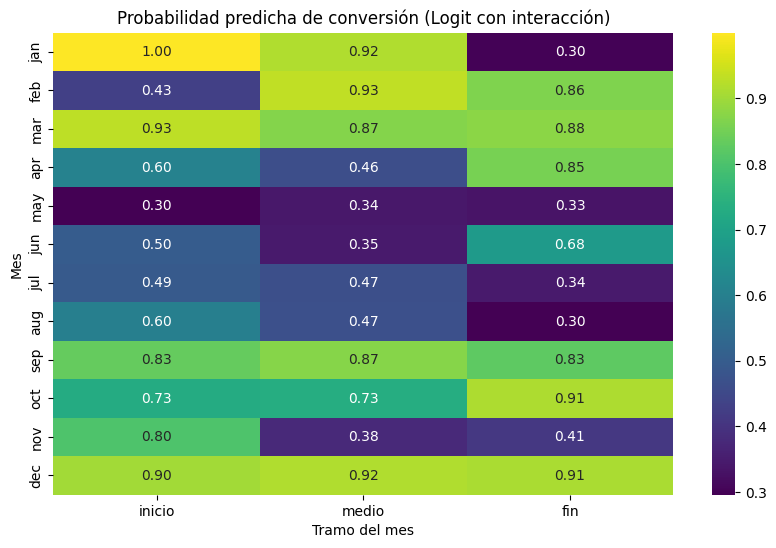

In [147]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.2f',
    cmap='viridis'
)
plt.title('Probabilidad predicha de conversión (Logit con interacción)')
plt.xlabel('Tramo del mes')
plt.ylabel('Mes')
plt.show()

## Conclusiones

Efecto Mes a Mes:

Fuerte, significativo desde el punto de vista estadístico y práctico. Es principal fuente de variación del CR

Efecto Intramensual:

Robusto, confirmado por 4 métodos independientes. 
Independiente de un mes, volumen, fluctuaciones aleatorias


El efecto intramensual del día se integra en el efecto mes a mes.
Es más débil, pero real y reproducible.

El test de razón de verosimilitud confirma que la interacción entre el mes y el tramo del mes aporta información estadísticamente significativa al modelo. Esto indica que el efecto del tramo no es homogéneo a lo largo del año, sino que depende del contexto mensual. En consecuencia, la planificación temporal de las campañas debe considerar combinaciones específicas de mes y tramo, en lugar de aplicar reglas generales sobre el momento del mes

Fuerte, significativo desde el punto de vista estadístico y práctico. Es principal fuente de variación del CR

Efecto Intramensual es robusto, confirmado por 4 métodos independientes.


# 3. Semana

In [133]:
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df['month_num'] = df['month'].map(month_map)

In [134]:
def add_weekday(df, assumed_year):
    tmp = df.copy()
    tmp['assumed_date'] = pd.to_datetime(
        dict(
            year=assumed_year,
            month=tmp['month_num'],
            day=tmp['day']
        ),
        errors='coerce'
    )
    tmp['weekday'] = tmp['assumed_date'].dt.day_name()
    return tmp

In [135]:
df_2008 = add_weekday(df, 2008)
df_2009 = add_weekday(df, 2009)
df_2010 = add_weekday(df, 2010)

In [136]:
pd.crosstab(df_2008['weekday'], df_2008['deposit'], normalize='index')

deposit,0,1
weekday,,
Friday,0.677596,0.322404
Monday,0.518365,0.481635
Saturday,0.321343,0.678657
Sunday,0.348324,0.651676
Thursday,0.595696,0.404304
Tuesday,0.541272,0.458728
Wednesday,0.525100,0.474900


In [137]:
pd.crosstab(df_2009['weekday'], df_2009['deposit'], normalize='index')

deposit,0,1
weekday,,
Friday,0.596749,0.403251
Monday,0.369391,0.630609
Saturday,0.708494,0.291506
Sunday,0.173759,0.826241
Thursday,0.526160,0.473840
Tuesday,0.511391,0.488609
Wednesday,0.527184,0.472816


In [138]:
pd.crosstab(df_2010['weekday'], df_2010['deposit'], normalize='index')

deposit,0,1
weekday,,
Friday,0.526160,0.473840
Monday,0.173759,0.826241
Saturday,0.596749,0.403251
Sunday,0.708494,0.291506
Thursday,0.527184,0.472816
Tuesday,0.369391,0.630609
Wednesday,0.511391,0.488609


In [139]:
def cr_by_weekday(df):
    return (
        df
        .groupby("weekday")["deposit"]
        .mean()
        .sort_values(ascending=False)
    )

In [140]:
cr_2008 = cr_by_weekday(add_weekday(df, 2008))
cr_2009 = cr_by_weekday(add_weekday(df, 2009))
cr_2010 = cr_by_weekday(add_weekday(df, 2010))

In [141]:
cr_compare = pd.concat(
    [cr_2008, cr_2009, cr_2010],
    axis=1,
    keys=["2008", "2009", "2010"]
)

cr_compare

,2008,2009,2010
weekday,,,
Saturday,0.678657,0.291506,0.403251
Sunday,0.651676,0.826241,0.291506
Monday,0.481635,0.630609,0.826241
Wednesday,0.474900,0.472816,0.488609
Tuesday,0.458728,0.488609,0.630609
Thursday,0.404304,0.473840,0.472816
Friday,0.322404,0.403251,0.473840


#### 2008
- Mejor: Saturday, Sunday
- Peor: Friday

#### 2009
- Mejor: Sunday
- Peor: Saturday

#### 2010
- Mejor: Monday
- Peor: Sunday

El "Mejor día de la semana" es un artefacto del año seleccionado, no una propiedad de los datos.

## Hipotesis 1
- H0: No existe asociación entre el día de la semana y la conversión, asumiendo el año Y.
- H1: El día de la semana está asociado con la conversión, asumiendo el año Y.

In [142]:
def chi_weekday(df):
    ct = pd.crosstab(df['weekday'], df['deposit'])
    return chi2_contingency(ct)

for year, d in zip([2008, 2009, 2010], [df_2008, df_2009, df_2010]):
    chi2, p, dof, _ = chi_weekday(d)
    print(year, "p-value:", p)

2008 p-value: 2.346818702685423e-75
2009 p-value: 3.2028688132915855e-92
2010 p-value: 3.202868813291769e-92


La prueba χ² no puede distinguir entre:

- un efecto de calendario real
- un efecto inducido por un calendario arbitrario

El día de la semana no es identificable porque el mismo conjunto de datos сonduce a diferentes interpretaciones del día de la semana dependiendo de un año arbitrario asumido

Significancia ≠ validez

La significancia estadística es robusta, pero el efecto no es identificable.

In [143]:
def cramers_v(df, cat_col, target_col):
    ct = pd.crosstab(df[cat_col], df[target_col])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

In [144]:
results = []

for year in [2008, 2009, 2010]:
    df_tmp = add_weekday(df, year)
    v = cramers_v(df_tmp, 'weekday', 'deposit')
    results.append({'assumed_year': year, 'cramers_v': v})

results_df = pd.DataFrame(results)
results_df

,assumed_year,cramers_v
0,2008,0.180464
1,2009,0.199004
2,2010,0.199004


Independientemente del año que asignemos arbitrariamente, la recodificación día + mes -> día laborable siempre crea una estructura estadística moderada.

La estructura es inducida por el calendario y no extraída de los datos.

- La clasificación de los días de la semana cambia.
- El "mejor día" es diferente para 2008, 2009 y 2010.

La interpretación del efecto es inestable.

Mismo tamaño del efecto no es igual a mismo significado del efecto.

## Conclusion 
La variable “día de la semana” no es identificable sin conocer el año.

Se evaluó la sensibilidad del análisis por día de la semana bajo distintos supuestos de asignación del año (2008, 2009 y 2010). Aunque en todos los escenarios se obtiene significancia estadística (p < 0,001) y tamaños de efecto moderados (V de Cramer está en rango 0,18–0,20), el orden de los días más y menos efectivos varía sustancialmente entre escenarios. Esto indica que las conclusiones dependen directamente del año asumido y que el efecto del día de la semana no es identificable de forma fiable a partir de los datos disponibles.

Con los datos disponibles no es posible identificar de forma fiable días específicos de la semana para priorizar contactos, ya que los resultados dependen de supuestos no verificables sobre el calendario.